# Predicting Song Popularity Using Spotify Audio Features and Last.fm Listener Data

**Target audience:** A&R and marketing teams at record labels who want a data-informed way to identify track characteristics associated with higher popularity.

**Core question:** Which audio features (e.g., danceability, energy, tempo) and audience engagement signals (Last.fm playcounts/listeners) are most associated with Spotify popularity?

**Datasets used:**
- **Last.fm API** (US top artists → top tracks, with playcount and listeners)
- **Spotify audio features dataset (Kaggle)** (audio features + popularity score)

**Why this matters:** If certain feature patterns are consistently linked to higher popularity, teams can prioritize tracks with similar profiles for playlist pitching, marketing spend, and content strategy.

**Key limitation:** The merge between Last.fm tracks and Spotify tracks is **string-based** (artist/track text), so match coverage will be imperfect. We quantify that explicitly after merging.

**Team members:** Niki Sivasankaravel, Yureni Roman


## Introduction

This analysis is intended for A&R and marketing teams at record labels who want to better understand whether measurable song characteristics are associated with stronger listener engagement and platform popularity. To explore this question, we combined Last.fm listener and playcount data with Spotify audio features such as danceability, energy, loudness, and tempo. Bringing these datasets together allows me to compare how songs perform across two different types of music information: user listening behavior and platform-level feature measurements.

This question matters because music professionals often need to decide which songs to promote, playlist, or invest in, yet song popularity is influenced by many factors and not just how a track sounds. The goal of this notebook is therefore not to claim that audio features fully determine popularity, but rather to test whether they provide useful directional insight when paired with listener data. The analysis focuses on the matched sample across both datasets, which allows for direct comparison but also introduces important limitations that are discussed below.

### Imports + setup

We import the libraries used across the notebook for API calls, data wrangling, and basic plotting. We also include a small delay to avoid hitting rate limits too quickly during the Last.fm API pull.


In [1]:
# We import the libraries required for API requests, data manipulation, visualization, and modeling. A small delay is included to avoid exceeding Last.fm API rate limits during data collection.
import numpy as np
import pandas as pd
import json
from pprint import pprint
import time
import matplotlib.pyplot as plt
import seaborn as sns

time.sleep(0.25)


In [2]:
import requests
# We wrap the Last.fm request in a function so we can reuse it across different endpoints.
# We also retried failed calls to make the data pull more reliable.

def lastfm_get(params, max_retries=3):
    for attempt in range(max_retries):
        r = requests.get("https://ws.audioscrobbler.com/2.0/", params=params, timeout=20)
        data = r.json()

       
        if "error" in data:
            msg = data.get("message", "")
            if "rate limit" in msg.lower() or "limit" in msg.lower():
                # back off and try again (briefly)
                time.sleep(2 * (attempt + 1))
                continue
            return None, data  

        return data, None
   # If all retries fail, return the last response for debugging.
    return None, {"error": "rate_limited", "message": "gave up after retries"}

In [3]:
url = "https://ws.audioscrobbler.com/2.0/"
country = "United States"
ARTIST_LIMIT = 100  
api_key = "beecbf6244bc57e7517d68c0d6662e37"

In [4]:
# We request the top artists in the United States and store the list for downstream track pulls.
params = {
    "method": "geo.getTopArtists",
    "country": "United States",
    "limit": 100,
    "api_key": "beecbf6244bc57e7517d68c0d6662e37",
    "format": "json"
}

resp = requests.get(url, params=params)
resp.raise_for_status()

data = resp.json()
top_artists = [a["name"] for a in data["topartists"]["artist"]]

**Scope choice:** To keep the analysis focused and API calls manageable, we restrict Last.fm pulls to:
- **Country:** United States  
- **Artists:** top 100 artists  
- **Tracks:** top 10 tracks per artist  

This creates a track-level dataset that is large enough for meaningful EDA/modeling while staying within rate limits.

In [5]:
# We loop through each top artist and pull their top tracks using Last.fm.
# This builds a track-level dataset (artist + track + playcount/listeners) for analysis and merging.

all_tracks = []

for i, artist in enumerate(top_artists):
    params = {
        "method": "artist.getTopTracks",
        "artist": artist,
        "api_key": api_key,
        "format": "json",
        "limit": 10
    }

    r = requests.get(url, params=params, timeout=20)
    d = r.json()

# We extract track fields and store them in a flat list of dictionaries for a clean DataFrame.
    if "error" in d or "toptracks" not in d:
        continue

    for t in d["toptracks"].get("track", []):
        all_tracks.append({
            "artist": artist,
            "track_name": t.get("name"),
            "listeners": int(t.get("listeners", 0)),
            "playcount": int(t.get("playcount", 0))
        })

    time.sleep(0.2)  

These next few blocks of code below help us organize the raw data pulled from the Last.fm API into a structured track-level dataset.

The individual track results collected during the API loop are converted into a Pandas DataFrame so they can be cleaned and analyzed more easily.

We also do quick validation checks to confirm the dataset pulled correctly, including reviewing the dataset shape and verifying the number of unique artists represented.

In [6]:
tracks_df = pd.DataFrame(all_tracks)
tracks_df.head(25)

,artist,track_name,listeners,playcount
0,PinkPantheress,Pain,1854604,34972222
1,PinkPantheress,Boy's a liar Pt. 2,1567231,22276399
2,PinkPantheress,I Must Apologise,1171242,15509337
3,PinkPantheress,Break It Off - Bonus,1066695,11160956
4,PinkPantheress,Attracted to You,1036227,17200919
5,PinkPantheress,Illegal,1023779,11324736
6,PinkPantheress,Stateside + Zara Larsson,888088,12141021
7,PinkPantheress,Just for Me,845124,10231700
8,PinkPantheress,Tonight,779805,11351460
9,PinkPantheress,Boy's a liar,746878,6544547


In [7]:
tracks_df.shape
tracks_df["artist"].nunique()

100

### Import Spotify dataset (Kaggle)

To expand beyond listener counts, we import a Spotify-based dataset from Kaggle that contains song-level audio features (e.g., danceability and energy) and a popularity score. This enables feature-based comparisons and prediction.

In [8]:
spotify_df = pd.read_csv("dataset.csv")
spotify_df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### Clean + merge datasets

Because artist and track names can vary by capitalization and spacing, we create standardized “clean” keys for both datasets. We then merge Spotify audio features onto our Last.fm track dataset to support feature-driven EDA and modeling.

In [9]:
# We standardize artist and track text fields to improve merge quality (lowercase + trim whitespace).

tracks_df["artist_clean"] = tracks_df["artist"].str.lower().str.strip()
tracks_df["track_clean"] = tracks_df["track_name"].str.lower().str.strip()

spotify_df["artist_clean"] = spotify_df["artists"].str.lower().str.strip()
spotify_df["track_clean"] = spotify_df["track_name"].str.lower().str.strip()

In [10]:
# We compare overlap of artist-track pairs across datasets to understand expected match rate.

keys_lastfm = set(zip(tracks_df["artist_clean"], tracks_df["track_clean"]))
keys_spotify = set(zip(spotify_df["artist_clean"], spotify_df["track_clean"]))

overlap = keys_lastfm.intersection(keys_spotify)

print("lastfm keys:", len(keys_lastfm))
print("spotify keys:", len(keys_spotify))
print("overlap keys:", len(overlap))
len(overlap)/len(keys_lastfm)

lastfm keys: 1000
spotify keys: 81207
overlap keys: 299


0.299

**Note about Merge Matching:**

The relatively low match rate between the Last.fm and Spotify datasets is an important limitation of the project, but it is also understandable. The two datasets were collected from different sources and do not represent the exact same universe of songs. Track and artist names may differ across platforms due to punctuation, featured artists, remixes, deluxe versions, live versions, or formatting differences. In addition, the Last.fm data was collected through an API pull of top U.S. artists, while the Spotify dataset comes from a separate Kaggle source with its own collection process and coverage. As a result, the merged dataset captures only the overlap between both sources rather than the full music market. This means the analysis should be interpreted as applying to the matched sample, not to every song on either platform.

In [11]:
# We use a Left join in order to keep Last.fm as the base dataset
merged_df = tracks_df.merge(
    spotify_df,
    how="left",
    on=["artist_clean", "track_clean"],
    suffixes=("_lastfm", "_spotify")
)

merged_df.shape

(1450, 27)

## Data Quality Checks

Before analysis, we check for duplicate artist-track pairs, missing values after the merge, and unusual numeric ranges. This ensures our merged dataset is usable and helps us interpret gaps created by unmatched joins.

In [12]:
# We duplicate the artist-track pairs (post-merge)
dupes = merged_df.duplicated(subset=["artist_clean", "track_clean"]).sum()
print("Duplicate artist-track pairs:", dupes)

Duplicate artist-track pairs: 450


In [13]:
# We also do a quick numeric check
print("Playcount min/max:", merged_df["playcount"].min(), merged_df["playcount"].max())
print("Listeners min/max:", merged_df["listeners"].min(), merged_df["listeners"].max())

Playcount min/max: 14614 58472086
Listeners min/max: 2794 4013520


### Missing values check

Missingness in Spotify feature columns mainly reflects unmatched songs from the merge rather than incomplete Spotify observations, which is why coverage is closely tied to merge success.

In [14]:
# We compute missingness as a percentage to quickly identify columns with limited coverage.
missing_pct = merged_df.isna().mean().sort_values(ascending=False)
missing_pct.to_frame("missing_pct").head(15)

,missing_pct
artists,0.483448
album_name,0.483448
Unnamed: 0,0.483448
track_name_spotify,0.483448
track_id,0.483448
key,0.483448
energy,0.483448
danceability,0.483448
explicit,0.483448
duration_ms,0.483448


In [15]:
# We merge coverage: what % of Last.fm tracks matched to Spotify features?
coverage = pd.DataFrame({
    "spotify_popularity_nonnull_pct": [merged_df["popularity"].notna().mean()],
    "danceability_nonnull_pct": [merged_df["danceability"].notna().mean()],
    "energy_nonnull_pct": [merged_df["energy"].notna().mean()]
})

coverage


,spotify_popularity_nonnull_pct,danceability_nonnull_pct,energy_nonnull_pct
0,0.516552,0.516552,0.516552


In [16]:
merged_df[["listeners", "playcount", "popularity", "danceability", "energy", "tempo", "loudness"]].describe()

,listeners,playcount,popularity,danceability,energy,tempo,loudness
count,1.450000e+03,1.450000e+03,749.000000,749.000000,749.000000,749.000000,749.000000
mean,1.449865e+06,1.780084e+07,55.049399,0.550794,0.720107,124.823336,-6.137697
std,7.989912e+05,1.145085e+07,33.770086,0.137536,0.198524,28.770825,2.819963
min,2.794000e+03,1.461400e+04,0.000000,0.202000,0.016700,64.934000,-24.639000
25%,8.840018e+05,9.202172e+06,4.000000,0.459000,0.594000,104.042000,-7.282000
50%,1.312566e+06,1.535995e+07,72.000000,0.556000,0.751000,121.864000,-5.453000
75%,1.891140e+06,2.425434e+07,80.000000,0.634000,0.893000,146.277000,-4.086000
max,4.013520e+06,5.847209e+07,97.000000,0.921000,0.988000,207.970000,-1.945000


## Key Variable Definitions

Before going into the results of the EDA, it's important to define the main Spotify variables used in the analysis.

**Spotify popularity:** A score from 0 to 100 that reflects a track’s relative popularity on Spotify. It is not a direct count of streams, but rather a platform-generated indicator of how popular a song is compared with others.

**Danceability:** Measures how suitable a track is for dancing based on rhythm, beat stability, tempo, and regularity.

**Energy:** Reflects the intensity and activity level of a track.

**Loudness:** The overall volume of the track in decibels.

**Speechiness:** Measures the presence of spoken words in a track.

**Acousticness:** Estimates how acoustic a track sounds.

**Instrumentalness:** Estimates the likelihood that a track contains no vocals.

**Liveness:** Captures the extent to which a song sounds like a live performance.

**Valence:** Reflects the musical positivity or emotional brightness of a song.

**Tempo:** The speed of the song in beats per minute.

## Exploratory Data Analysis

The EDA section is designed to answer three main questions:
- First, what does the popularity distribution of matched songs look like?
- Second, do audio features such as danceability, energy, loudness, and tempo appear related to popularity?
- Third, are there artist-level or feature-level patterns that may help explain which songs perform better on the platform?

These visuals and summary tables provide context for the analysis before moving into feature engineering and modeling. They're especially important because the merged dataset is only a partial overlap between the two sources, meaning that interpretation should focus on broad patterns rather than universal claims about all songs.

In [17]:
# Outlier-aware clipping boundaries (winsorization) for skewed engagement columns
bounds = {}
for col in ["playcount", "listeners"]:
    lo, hi = merged_df[col].quantile([0.01, 0.99]).tolist()
    bounds[col] = (lo, hi)

bounds

{'playcount': (263782.61, 53648674.0),
 'listeners': (29526.15, 3712657.479999998)}

In [47]:
# Group songs by tempo category to compare average popularity and engagement.
# This helps show whether slower, medium, or faster songs tend to differ
# in Spotify popularity, listener counts, and playcounts.

popularity_by_tempo = (
    merged_df.dropna(subset=["popularity", "tempo_category"])
    .groupby("tempo_category")
    .agg(
        track_count=("track_name_spotify", "count"),
        avg_popularity=("popularity", "mean"),
        avg_listeners=("listeners", "mean"),
        avg_playcount=("playcount", "mean")
    )
    .round(2)
)

popularity_by_tempo

,track_count,avg_popularity,avg_listeners,avg_playcount
tempo_category,,,,
fast,404,46.55,1764455.66,20500959.25
slow,345,65.00,1891772.39,22960721.76


In [18]:
# Artist-level: who dominates engagement?
artist_engagement = (
    merged_df.groupby("artist")[["playcount", "listeners"]]
    .sum()
    .sort_values("playcount", ascending=False)
    .head(10))

artist_engagement

,playcount,listeners
artist,,
The Killers,1279170932,104176260
Linkin Park,1272141317,112222586
Nirvana,1035752663,109235489
Red Hot Chili Peppers,966160629,105351878
Arctic Monkeys,952360094,63412674
Lady Gaga,858442072,70376315
Radiohead,829707728,57422960
Paramore,767706193,59226049
Weezer,634293987,71505324


In [19]:
# Popularity by artist (requires Spotify match)
artist_popularity = (
    merged_df.dropna(subset=["popularity"])
    .groupby("artist")["popularity"]
    .mean()
    .sort_values(ascending=False)
    .head(10))

artist_popularity

artist
Bad Bunny         95.500000
Joji              94.000000
Beyoncé           93.000000
Harry Styles      92.000000
J. Cole           88.000000
Olivia Rodrigo    87.400000
Doja Cat          84.333333
Kendrick Lamar    84.000000
Tate McRae        84.000000
Drake             84.000000
Name: popularity, dtype: float64

### Interpreting Spotify Popularity

Spotify popularity should be interpreted carefully because it's not the same as a raw stream count. Instead, it's a relative score assigned by Spotify that reflects how popular a track is on the platform compared with others. Because it is a ranking-style measure rather than a uniform scale, songs are not expected to be evenly distributed across all values from 0 to 100. This score is still useful for the analysis because it gives a standardized way to compare broad differences in platform traction across matched songs.

In [20]:
# This is the count of matched vs unmatched tracks
match_table = pd.DataFrame({
    "matched_to_spotify": [merged_df["popularity"].notna().sum()],
    "unmatched": [merged_df["popularity"].isna().sum()],
    "match_rate": [merged_df["popularity"].notna().mean()]
})

match_table

,matched_to_spotify,unmatched,match_rate
0,749,701,0.516552


In [21]:
popular_tracks = merged_df[merged_df["popularity"].notna()].copy()
popular_tracks.shape

(749, 27)

In [22]:
merged_df.groupby("artist")["playcount"].sum().sort_values(ascending=False).head(10)

artist
The Killers              1279170932
Linkin Park              1272141317
Nirvana                  1035752663
Red Hot Chili Peppers     966160629
Arctic Monkeys            952360094
Lady Gaga                 858442072
Radiohead                 829707728
Paramore                  767706193
Weezer                    634293987
The Neighbourhood         630467930
Name: playcount, dtype: int64

## Visualizations

The following visualizations explore patterns in the merged dataset by examining the distribution of song popularity and the relationships between key Spotify audio features (such as danceability and energy) and track popularity. These plots help identify potential trends and provide an intuitive view of how musical characteristics may relate to song success.

### Histogram: Distribution of Spotify Popularity

This histogram shows the distribution of Spotify popularity scores across the merged dataset. Visualizing this distribution helps us understand how popularity is spread among tracks and whether most songs fall into lower, moderate, or higher popularity ranges.

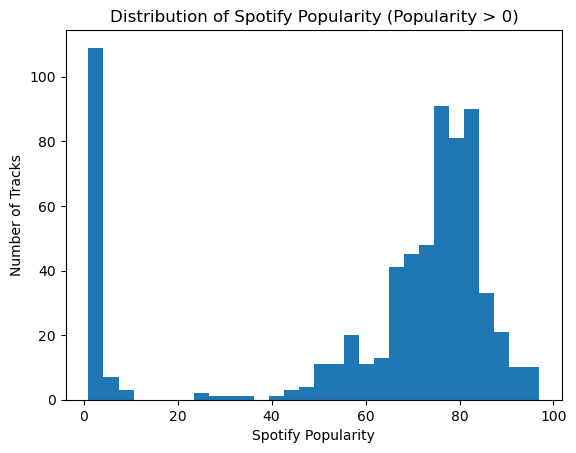

In [23]:
# We first filter the dataset to keep tracks with valid popularity values.

popular_tracks = merged_df[merged_df["popularity"] > 0]

# We create a histogram to show how Spotify popularity scores are distributed across tracks.
plt.hist(popular_tracks["popularity"], bins=30)
plt.title("Distribution of Spotify Popularity (Popularity > 0)")
plt.xlabel("Spotify Popularity")
plt.ylabel("Number of Tracks")
plt.show()

This histogram shows the distribution of Spotify popularity scores across tracks in the dataset. Most songs fall within the moderate to high popularity range (approximately 60–85), indicating that the dataset contains many well-known tracks rather than entirely obscure songs. A small number of songs have very low popularity values, which may reflect older or less actively streamed tracks. The popularity distribution shows that most matched tracks are concentrated in a middle-to-upper range rather than being evenly spread across all values. For the target audience, this suggests that the merged sample contains songs with at least some measurable platform traction, but still enough variation to compare relatively weaker and stronger performers. In other words, the data is useful for identifying broad patterns in song performance, even if it does not represent the entire market.

### Scatterplot: Danceability vs Song Popularity

This scatter plot examines the relationship between danceability and Spotify popularity. Each point represents a track, allowing us to visually assess whether songs with higher danceability tend to be associated with higher popularity levels.

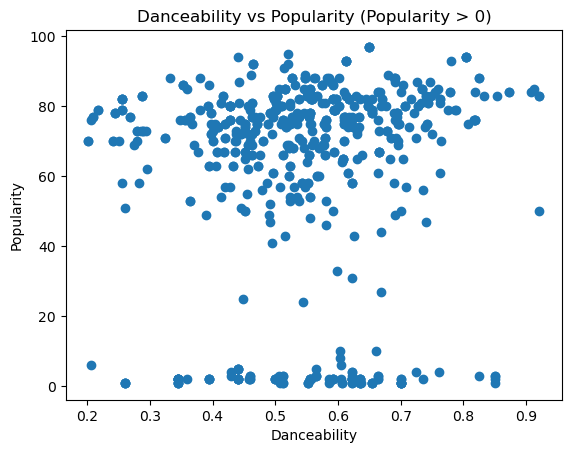

In [24]:
filtered_df = merged_df[merged_df["popularity"] > 0]

plt.scatter(filtered_df["danceability"], filtered_df["popularity"])
plt.xlabel("Danceability")
plt.ylabel("Popularity")
plt.title("Danceability vs Popularity (Popularity > 0)")
plt.show()

### Regression Trend Line: Danceability vs Popularity with Trend Line

This visualization adds a regression trend line to the danceability and popularity relationship. The trend line provides a clearer indication of whether there is a positive, negative, or minimal relationship between danceability and song popularity.

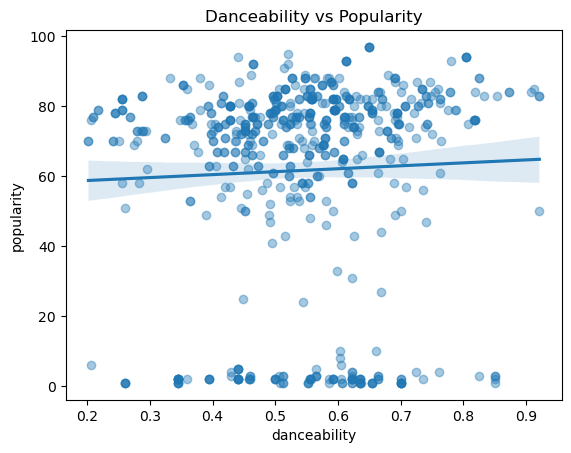

In [25]:
sns.regplot(
    data=filtered_df,
    x="danceability",
    y="popularity",
    scatter_kws={"alpha":0.4}
)

plt.title("Danceability vs Popularity")
plt.show()

The relationship between danceability and popularity appears positive but weak. This suggests that danceability may matter somewhat, but it is clearly not strong enough on its own to explain why a song becomes more popular. For A&R and marketing teams, this means audio features may offer directional clues, but they should not be treated as standalone predictors of success. Songs can share similar musical characteristics and still perform very differently because of factors beyond the track’s sound.

### Heatmap: Correlation Between Audio Features and Popularity

This heatmap displays correlations between key Spotify audio features and the popularity metric. By visualizing these relationships together, we can identify which musical characteristics appear more strongly associated with popularity.

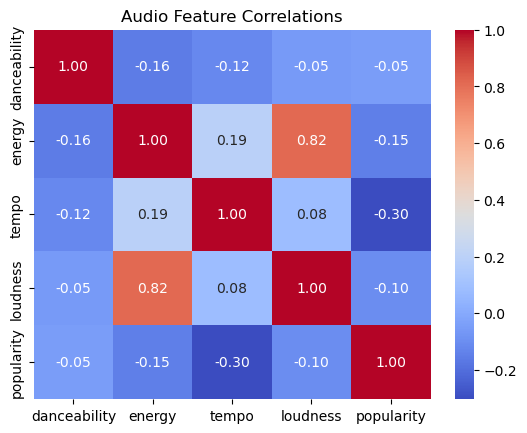

In [26]:
# We calculate correlations between selected Spotify audio features and popularity.

corr = merged_df[
    ["danceability","energy","tempo","loudness","popularity"]
].corr()



plt.title("Audio Feature Correlations")
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

### Interpreting the Correlations

The generally low correlations indicate that song popularity is not strongly explained by audio features alone. This is not surprising in a real-world music setting. Audio features describe what a song sounds like, but popularity is also affected by release timing, playlist placement, marketing support, artist reputation, social media momentum, and cultural trends. In other words, these features are relevant pieces of the picture, but they do not capture the full business context behind why some songs gain more traction than others.

### Bar Chart: Top Artists by Total Playcount (Last.fm)

This bar chart shows which artists dominate total playcount in our Last.fm sample. This matters because heavy concentration can influence averages and model interpretation.

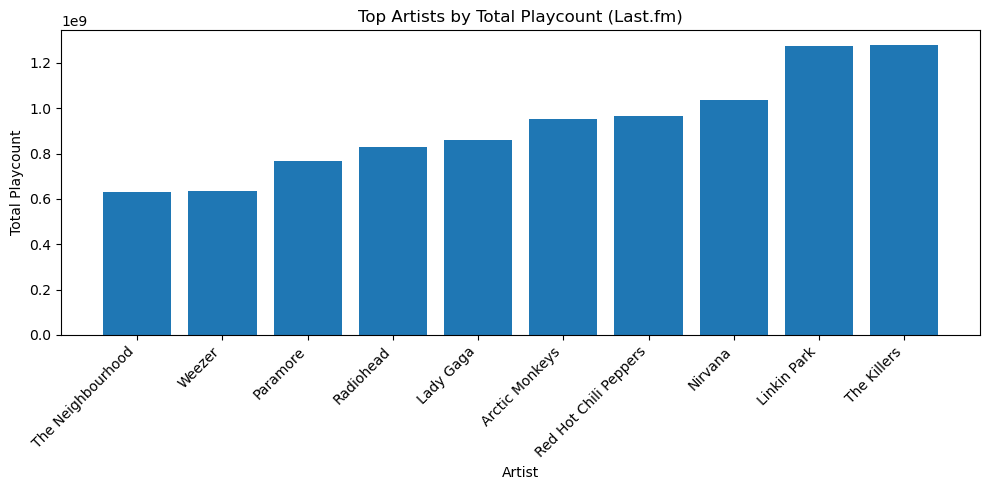

In [27]:
# Identify the artists with the highest total playcounts in the dataset

top_artists = (
    merged_df.groupby("artist")["playcount"]
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)

plt.figure(figsize=(10, 5))
plt.bar(top_artists.index, top_artists.values)
plt.title("Top Artists by Total Playcount (Last.fm)")
plt.ylabel("Total Playcount")
plt.xlabel("Artist")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

This chart shows the artists that account for the highest total playcounts in the dataset. The results indicate that listening activity is heavily concentrated among a small number of artists. This concentration is important because artist popularity may influence song-level playcounts and could partially affect patterns observed in the regression analysis.

## Feature Engineering

Feature engineering was used to test whether combinations or transformations of the original audio features could better capture patterns related to song popularity. In addition to the raw Spotify variables, we created interaction and transformed features such as dance_energy and loudness_abs to explore whether combined audio traits were more informative than standalone measures. These engineered features were then included in the regression models.

In [28]:
# Interaction feature
merged_df["dance_energy"] = merged_df["danceability"] * merged_df["energy"]

# Tempo category using apply
merged_df["tempo_category"] = merged_df["tempo"].apply(
    lambda x: "fast" if x > 120 else "slow"
)

# Loudness magnitude
merged_df["loudness_abs"] = merged_df["loudness"].abs()

In [29]:
merged_df[["danceability",
"energy",
"loudness",
"speechiness",
"acousticness",
"instrumentalness",
"liveness",
"valence",
"tempo",
"dance_energy",
"loudness_abs"]].describe()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,dance_energy,loudness_abs
count,749.000000,749.000000,749.000000,749.000000,749.000000,749.000000,749.000000,749.000000,749.000000,749.000000,749.000000
mean,0.550794,0.720107,-6.137697,0.068965,0.155483,0.039999,0.174543,0.505533,124.823336,0.392301,6.137697
std,0.137536,0.198524,2.819963,0.066672,0.234442,0.140325,0.139804,0.221060,28.770825,0.131560,2.819963
min,0.202000,0.016700,-24.639000,0.024300,0.000005,0.000000,0.021000,0.039700,64.934000,0.008500,1.945000
25%,0.459000,0.594000,-7.282000,0.033700,0.002830,0.000000,0.090900,0.328000,104.042000,0.304500,4.086000
50%,0.556000,0.751000,-5.453000,0.047500,0.033900,0.000018,0.115000,0.514000,121.864000,0.413402,5.453000
75%,0.634000,0.893000,-4.086000,0.073700,0.206000,0.001650,0.205000,0.698000,146.277000,0.480384,7.282000
max,0.921000,0.988000,-1.945000,0.442000,0.979000,0.914000,0.853000,0.968000,207.970000,0.746834,24.639000


## Modeling

We use two predictive models to help us evaluate whether Spotify audio features can explain or predict differences in song popularity.

**Linear Regression:**  Used to predict the numerical popularity score of a song.

**Logistic Regression:**  Used to classify whether a song is considered a "hit".

## Linear Regression Model

The first model uses linear regression to estimate how audio features relate to Spotify popularity as a continuous outcome. This model is useful because it allows the analysis to examine the direction and relative strength of associations between each feature and popularity while holding the other variables constant. Although the model does not imply causation, it helps identify which features appear most closely aligned with higher or lower predicted popularity in this matched sample.

In [30]:
from sklearn.model_selection import train_test_split
features = [
"danceability",
"energy",
"loudness",
"speechiness",
"acousticness",
"instrumentalness",
"liveness",
"valence",
"tempo",
    "dance_energy",   # engineered
    "loudness_abs"    # engineered
]


In [31]:
# We create a new dataframe containing only the feature columns and popularity.
model_df = merged_df[features + ["popularity"]].dropna()

X = model_df[features]
y = model_df["popularity"]


In [32]:
# Split the dataset into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)


In [33]:
from sklearn.linear_model import LinearRegression

# We train the model using the training data.
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# We use the trained model to generate predictions for the test set.
y_pred = model.predict(X_test)

# We first calculate the mean squared error between predicted and actual values.
# Then, we calculate the R-squared value for the model.
print("R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.12996134974120133
RMSE: 30.904855003243302


The linear regression model achieved an R² of about 0.13 and an RMSE of about 31, indicating that audio features explain only a modest share of the variation in Spotify popularity.

In [35]:
# Create a dataframe that shows each feature and its model coefficient.

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_.flatten()
}).sort_values(by="Coefficient", ascending=False)

coef_df

,Feature,Coefficient
0,danceability,37.798436
6,liveness,27.018800
5,instrumentalness,7.827666
1,energy,1.249586
2,loudness,0.059673
10,loudness_abs,-0.059673
8,tempo,-0.262146
4,acousticness,-6.148181
7,valence,-25.190687
9,dance_energy,-43.621894


The regression coefficients show the direction and relative strength of the relationship between each feature and predicted popularity, holding the other variables constant. Positive coefficients suggest that higher values of a feature are associated with higher predicted popularity, while negative coefficients suggest the opposite. Features with larger absolute coefficients appear more influential within this model. However, these coefficients should not be interpreted as causal effects. They show associations in this dataset, not proof that changing a feature would directly cause popularity to rise or fall.

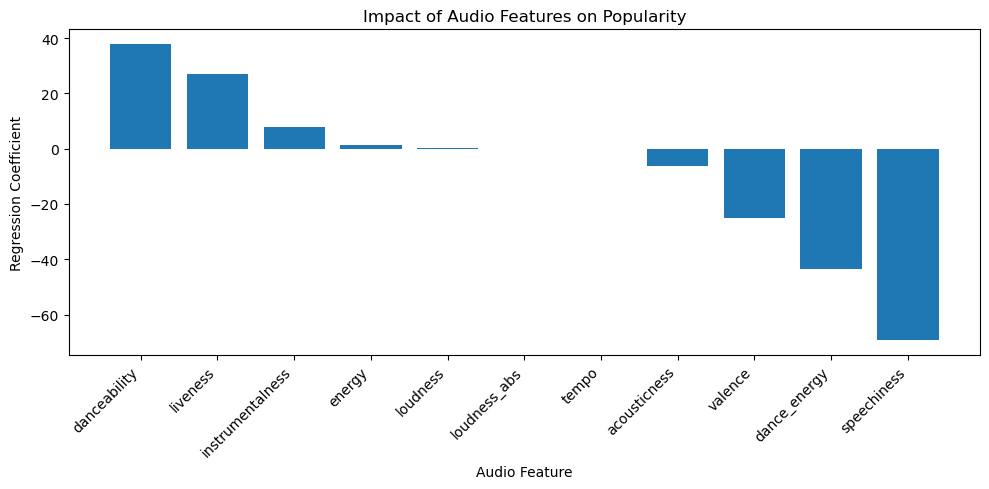

In [36]:
plt.figure(figsize=(10,5))
plt.bar(coef_df["Feature"], coef_df["Coefficient"])
plt.title("Impact of Audio Features on Popularity")
plt.xlabel("Audio Feature")
plt.ylabel("Regression Coefficient")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The regression coefficients show the direction and relative strength of each feature’s relationship with predicted popularity, holding the others constant. Some features appear positively associated with popularity and others negatively associated, but these coefficients should be interpreted cautiously because the model’s overall fit is modest. This suggests that audio features may offer directional insight, but they do not explain song success on their own.

## Logistic Regression Model

The second model reframes the problem as a classification task by predicting whether a song falls into a higher-popularity category. This approach is useful because record labels and marketing teams are often interested in identifying which songs are more likely to break into a stronger performance tier rather than only predicting an exact popularity score. The logistic model therefore complements the linear model by asking whether the same audio features can help distinguish relatively stronger-performing songs from weaker-performing ones.

In [37]:
# We define hit songs as those with popularity score >= 70
merged_df["hit"] = (merged_df["popularity"] >= 70).astype(int)

In [38]:
model_df = merged_df[features + ["hit"]].dropna()

In [39]:
X = model_df.drop(columns=["hit"])
y = model_df["hit"]

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [41]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [42]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

y_pred = log_model.predict(X_test)
print(classification_report(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.52      0.47      0.50        59
           1       0.68      0.71      0.70        91

    accuracy                           0.62       150
   macro avg       0.60      0.59      0.60       150
weighted avg       0.61      0.62      0.62       150

Precision: 0.6770833333333334
Recall: 0.7142857142857143
F1 Score: 0.6951871657754011


**Note:** For the classification model, we focus more on precision, recall, F1-score, and ROC-AUC than on raw accuracy alone. Accuracy can be misleading when classes are imbalanced, while these other metrics provide a better sense of how well the model identifies stronger-performing songs and balances false positives versus false negatives. This makes them more useful for evaluating the practical value of the classifier.

In [43]:
from sklearn.metrics import roc_auc_score
y_probs = log_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_probs)
print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.6165021419258707


**Note:** The logistic regression model achieved about 0.62 accuracy and a ROC-AUC of about 0.65, suggesting that audio features provide some directional signal for identifying higher-popularity songs, but prediction remains limited.

In [44]:
# We then save collected Last.fm track data for our SQL Jupyter Notebook
tracks_df.to_csv("lastfm_tracks.csv", index=False)

## Conclusion

This analysis was designed to evaluate whether song-level audio features and listener engagement data can provide meaningful insight into music popularity. The findings suggest that variables such as danceability, energy, tempo, and loudness do show some relationship with popularity, but those relationships are generally modest. The relatively weak correlations and model results indicate that popularity is influenced by far more than a song’s measurable audio characteristics.

From a strategic perspective, this suggests that while audio features may capture aspects of a song’s sonic profile, they cannot fully explain why certain tracks gain widespread traction. Factors such as release timing, artist reputation, playlist placement, promotional support, and broader cultural attention likely play a significant role but were not captured in this analysis. Audio features may therefore be most useful as part of a broader decision-making framework rather than as a standalone predictor of success. When combined with listener engagement data and market context, they can still provide directional insight into which songs share characteristics associated with stronger platform traction.

While this analysis provides an initial look at how audio characteristics relate to listener popularity, these findings should be interpreted as exploratory rather than definitive. With additional time and more comprehensive datasets, the ability to explain variation in music popularity could be significantly improved.

### Future Work and Additional Data

If more time were available, this analysis could be extended in some different ways:

**Release and Metadata Information:**
Adding release date, genre labels, and artist metadata would allow examination of how timing, genre positioning, and artist context influence a song’s ability to gain traction.

**Playlist and Platform Exposure Data:**
Incorporating playlist placement data and platform promotion metrics would help capture one of the most important drivers of discovery and streaming growth.

**Streaming and Chart Performance Data:**
Integrating streaming counts or Billboard chart performance would make it possible to validate whether listener engagement patterns align with broader commercial success.

**Expanded Dataset Coverage**
Increasing the overlap between datasets and expanding the number of analyzed songs would improve the representativeness of the sample and strengthen confidence in the resulting insights.
Together, these extensions would provide a more complete and decision-relevant understanding of the factors that shape music popularity for A&R and marketing teams.